<a href="https://colab.research.google.com/github/Glockrover/LearnTensorFlow/blob/main/Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Classification with Neural network in TensorFlow

In this notebook we're are going to learn how to write a neural network for classification problems.

A classificationis where you try to classify something as one thing or another.

A few types of classifaction problems:

* Binary classification
* Multiclass classification
* Multilabel classification

## Creating day to view and fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000 examples

n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)



In [2]:
# Check out features anf labels
X[:3], y[:3]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

Our data is a little hard to understand right now... let's visualize it!

In [3]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


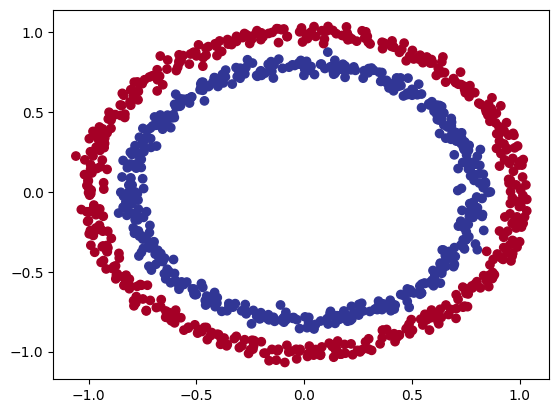

In [4]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

**Exercise:** Before pushing forward, spend 10 minutes playing arond with [playgrouund.tensorflow.org](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.84405&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) building and running differernt neural networks. See what happens when you change different hyperparameters.

## Input and out shapes

In [5]:
# Check the shape of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
# How many samples we're working with
len(X), len(y)

(1000, 1000)

In [7]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in modelling

The steps in modelling with TensorFlow are typically:

1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate...

In [8]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

def create_model():
  # 1. Create the model using the Sequential APi
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(1)
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])
  return model

# Creating our model
model1 = create_model()

# 3. Fit the model
model1.fit(X,y,epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4780 - loss: 3.8575
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4830 - loss: 1.1826
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4890 - loss: 0.7240
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4850 - loss: 0.7032
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4890 - loss: 0.6971
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4890 - loss: 0.6951
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4870 - loss: 0.6945
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 0.6944
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4630 - loss: 0.6943
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4550 - loss: 0.6943
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4570 - loss: 0.6944
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [9]:
# Let's try and improve our model
model1.fit(X,y, epochs=200, verbose=0)

# 4. Evaluate our mode
model1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4730 - loss: 0.6933  


[0.6932879686355591, 0.4729999899864197]

Since we're working on a binary classification problem and our model is getting around ~47% accuracy... it's peforming as if it's guessing.

So let's step thing up a notch and add an extra layer.

In [10]:
# Set the random seed
tf.random.set_seed(42)

def create_model():
  # 1. Create the model with 2 layers
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(1),
      tf.keras.layers.Dense(1)
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])
  return model

# Creating our model
model2 = create_model()

# 3. Fit the model
model2.fit(X,y,epochs=100, verbose=0)


In [11]:
model2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4920 - loss: 0.6938 


[0.693792462348938, 0.492000013589859]

In [12]:
circles["label"].value_counts()

,count
label,
1,500
0,500


## Improving our model

Let's look into our bag of trick to see how we can improve our model.

1. Create a model - we might add more layers or increase the number of hidden units within a layer.
2. Compilling a model - here we might want to choose a different optimazation function as Adam instead of SGD.
3. Fitting a model - perhaps we might fit our model for more epochs (leave it traing for longer )

In [13]:
def create_model():
  # 1. Create the model using the Sequential APi
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(100),
      tf.keras.layers.Dense(10),
      tf.keras.layers.Dense(1),
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
  return model

# Creating our model
model3 = create_model()

# 3. Fit the model
model3.fit(X,y,epochs=100, verbose=0)


In [14]:
# 4. Evaluate the model
model3.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4880 - loss: 0.6950  


[0.695003867149353, 0.4880000054836273]

In [15]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,965 (15.49 KB)

 Trainable params: 1,321 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,644 (10.33 KB)

To visualize our model's predictions, let's create a function `plot_decision_boundary` This function will:

* Take in a trained model, feature (X) and labels (y)
* Create a meshgrid o fhte differnret feature values
* Make predictions across the mesh
* Plot decision boundary

In [16]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary created by a model predicting X and y labels
  """

  # Defind the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - min(X[:, 0]), X[:, 0].max() + max(X[:, 0])
  y_min, y_max = X[:, 1].min() - min(X[:, 1]), X[:, 1].max() + max(X[:, 1])

  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # We have to reshape our predictions
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decisionn boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step
doing binary classification


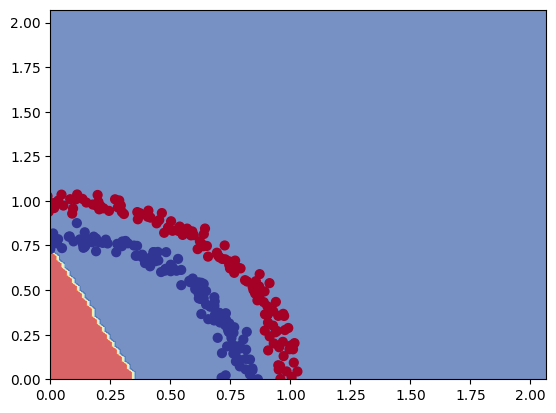

In [17]:
# Check out the predictions our model is making
plot_decision_boundary(model3, X, y)

In [18]:
# Let's see if our model can be used for a regression problem....

tf.random.set_seed(42)

# Create some regression data

X_regression = tf.range(0, 1000, 5)
y_regression = tf.range(100, 1100, 5)

# Split our regression data into training and test sets
X_reg_train = X_regression[:150]
y_reg_train = y_regression[:150]

X_reg_test = X_regression[150:]
y_reg_test = y_regression[150:]

# Fit our model to the regression data
# model3.fit(X_reg_train, y_reg_train, epochs=100, verbose=0)

# this cell will error because our model expect a binary classification not a regression

It looks like our classification model `model3` couldn't be directly used for the regression problem. This is because the model was built to expect 2 features (from `X` in `make_circles`), but our regression data `X_reg_train` only has 1 feature. Also, `model3` uses `BinaryCrossentropy` and `accuracy` which are suitable for classification, not regression.

Let's create a dedicated model for this regression task.

In [19]:
tf.random.set_seed(42)

# 1. Create a model for regression
model_regression = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(1,)), # Input layer with 1 feature
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1) # Output layer for a single regression value
])

# 2. Compile the model with regression-specific loss and optimizer
model_regression.compile(loss=tf.keras.losses.mae, # Mean Absolute Error for regression
                         optimizer=tf.keras.optimizers.Adam(),
                         metrics=['mae'])

# 3. Fit the model to the regression data
model_regression.fit(X_reg_train, y_reg_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# 4. Evaluate the regression model
model_regression.evaluate(X_reg_test, y_reg_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 62.7692 - mae: 62.7692 


[62.769168853759766, 62.769168853759766]

Now that we have a regression model, let's make some predictions and visualize them.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


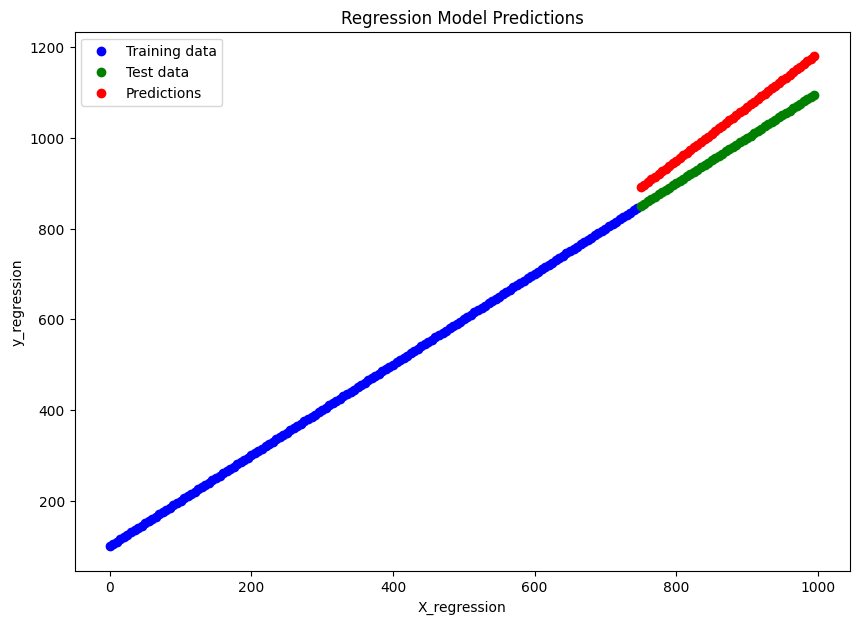

In [21]:
# Make predictions
y_reg_pred = model_regression.predict(X_reg_test)

# Plot the predictions
plt.figure(figsize=(10, 7))
plt.scatter(X_reg_train, y_reg_train, c='b', label='Training data')
plt.scatter(X_reg_test, y_reg_test, c='g', label='Test data')
plt.scatter(X_reg_test, y_reg_pred, c='r', label='Predictions')
plt.legend()
plt.title('Regression Model Predictions')
plt.xlabel('X_regression')
plt.ylabel('y_regression')
plt.show()

Let's try build our first neural network with a non-linear activation function.

In [22]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='relu')
])

# 2. Compile the mode
model5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=['accuracy'])

# 3. Fit the model
history = model5.fit(X, y, epochs=100)




Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4730 - loss: 4.6111   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4720 - loss: 4.5766 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.5675 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.5590 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.5539 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 4.5492 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 4.5365 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 4.5049 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.4897 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 4.4810 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.4758 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [23]:
# Time to replicate the multi-layer neural network from TensorFlow Playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Changed to 1 unit with sigmoid for binary classification
])

# 2. Compile the model
model6.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=['accuracy'])

# 3. Fit the model
history = model6.fit(X, y, epochs=200, verbose=0)

In [24]:
# Evaluate the model
model6.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.1084  


[0.10844898223876953, 0.9829999804496765]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
doing binary classification


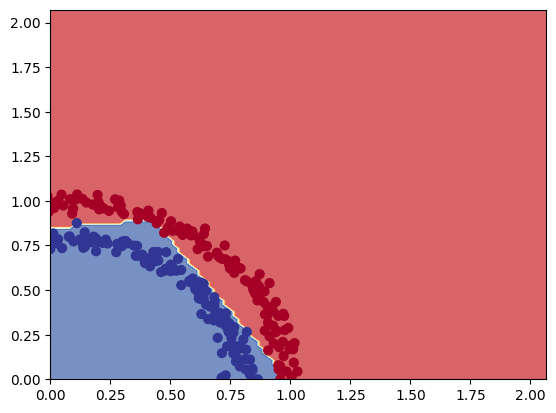

In [25]:
# How does our model prediction look
plot_decision_boundary(model6, X, y)

In [26]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, 'sigmoid')
])

# 2. Compile the model
model7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=['accuracy'])

# 3. Fit the model

history = model7.fit(X, y, epochs=200, verbose=0)

In [27]:
model7.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9960 - loss: 0.0693  


[0.06934893876314163, 0.9959999918937683]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step
doing binary classification


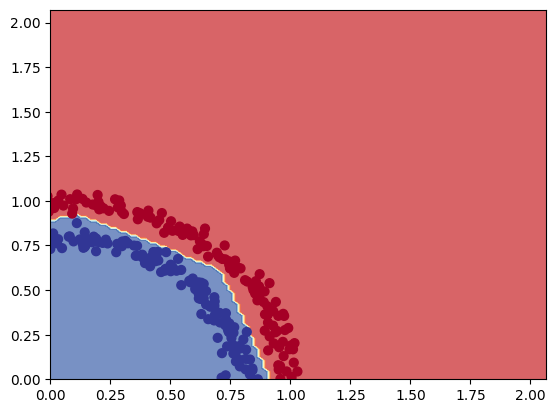

In [28]:
# Let' visualize our increadible metrics
plot_decision_boundary(model7, X, y)


Now we've learnedd the concept of linear and non-linear functions, let's see them in action

In [29]:
# Create a toy tensor (similar to the data we pass into our models)

A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

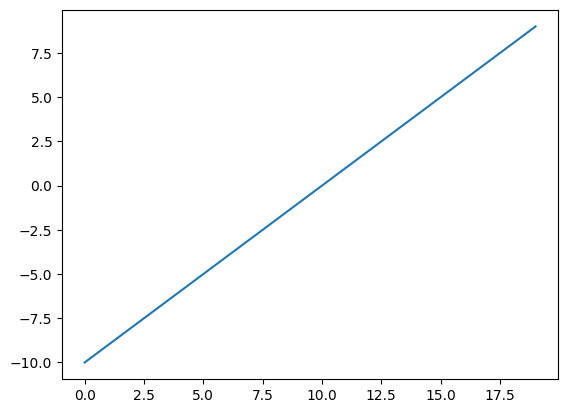

In [30]:
# Viusalize our toy tensor
plt.plot(A);

In [31]:
# Let's start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))

def sigmoid(x):
  return 1 / (1 + tf.math.exp(-x))

# use the sigmoid function on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

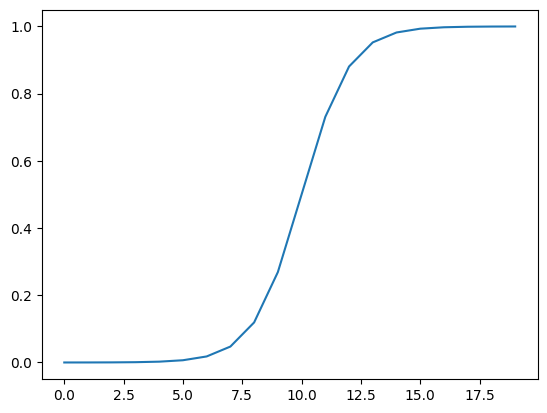

In [32]:
# Plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A));

In [33]:
# Let's recreate the relu function

def relu(x):
  return tf.maximum(0, x)

# use the relu function on our toy tensor
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

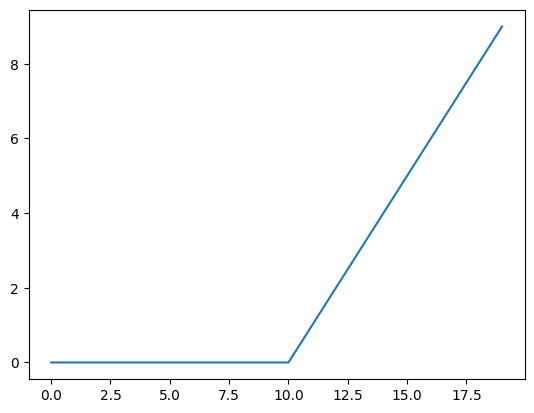

In [34]:
# Let's plot the relu function
plt.plot(relu(A));

In [35]:
# Let's try the linear activation function
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

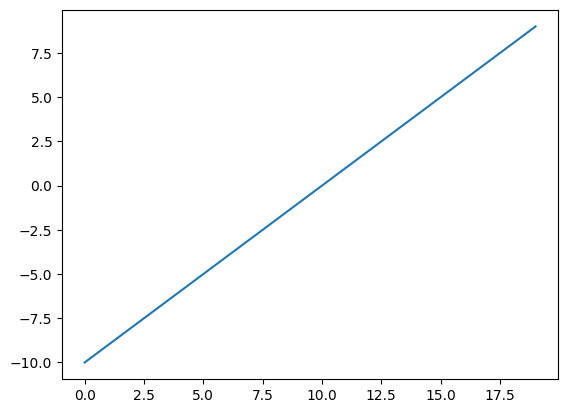

In [36]:
# Does the linear activation function change anything?
plt.plot(tf.keras.activations.linear(A));

## Evaluating and improving our classifcation

So far we've been traing and testing on the same dataset...

However, in machine learning this is basically a sin.

So let's create training and test set.

In [37]:
# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [38]:
# Let's recreate a model to fit on the training data and evaluate on teh testing set

# Set random seed
tf.random.set_seed(42)

# 1. Create the model same as model6
model8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model8.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['accuracy'])

# 3. Fit the model
history = model8.fit(X_train, y_train, epochs=100, verbose=0)

In [39]:
# 4. Evalute the model on the test dataset
model8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9650 - loss: 0.0945  


[0.09450830519199371, 0.9649999737739563]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step
doing binary classification


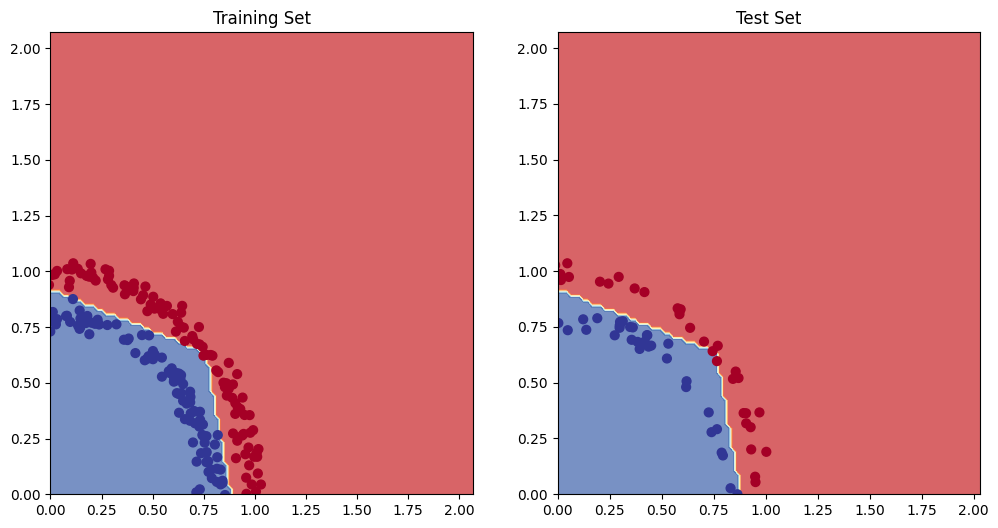

In [40]:
# Plot the decision boundaries for the trainging and test set
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Training Set')
plot_decision_boundary(model8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test Set')
plot_decision_boundary(model8, X_test, y_test)

## Plot the loss (or training) curves

In [41]:
# Connvert the history object into a DataFrame
pd.DataFrame(history.history)

,accuracy,loss
0,0.49250,0.694913
1,0.52250,0.686189
2,0.55000,0.682628
3,0.58375,0.677522
4,0.57625,0.667335
...,...,...
95,0.98750,0.044862
96,0.98750,0.044569
97,0.98750,0.044277
98,0.98750,0.044001


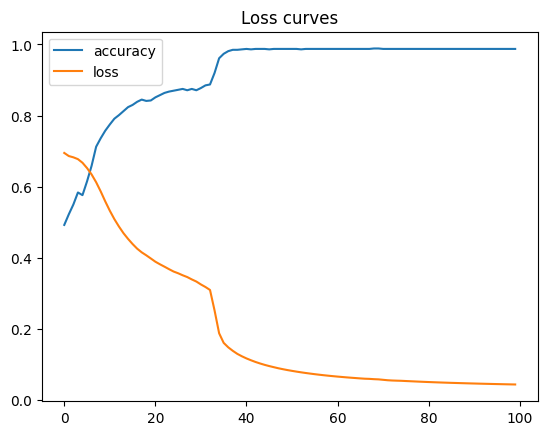

In [42]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title('Loss curves')
plt.show();

## Finding the best learning rate

To find the ideal learning rate (the learning rate where the loss decrease the most during training) we're going to use the following steps:

* A learning rate **callback** - you can think of a callback as an extra piece of functionality, you can add to *while* it's training.

* Another model (we could use the same one as above, but we're going to practice building more models)

* A modified loss curves plot

In [43]:
# Building a model

# Set random seed
tf.random.set_seed(42)

# 1. Create a mode (same as model8)
model9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model9.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['accuracy'])

# 3. Creating a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 4. Fiting the model (passing lr_scheduler callback)
history = model9.fit(X, y, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4950 - loss: 0.6911 - learning_rate: 1.0000e-04
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4990 - loss: 0.6910 - learning_rate: 1.1220e-04
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5020 - loss: 0.6909 - learning_rate: 1.2589e-04
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5020 - loss: 0.6909 - learning_rate: 1.4125e-04
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5070 - loss: 0.6908 - learning_rate: 1.5849e-04
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5030 - loss: 0.6907 - learning_rate: 1.7783e-04
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5020 - loss: 0.6906 - learning_rate: 1.9953e-04
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5010 - loss: 0.6904 - learning_rate: 2.2387e-04
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5010 - loss: 0.6903 - learning_

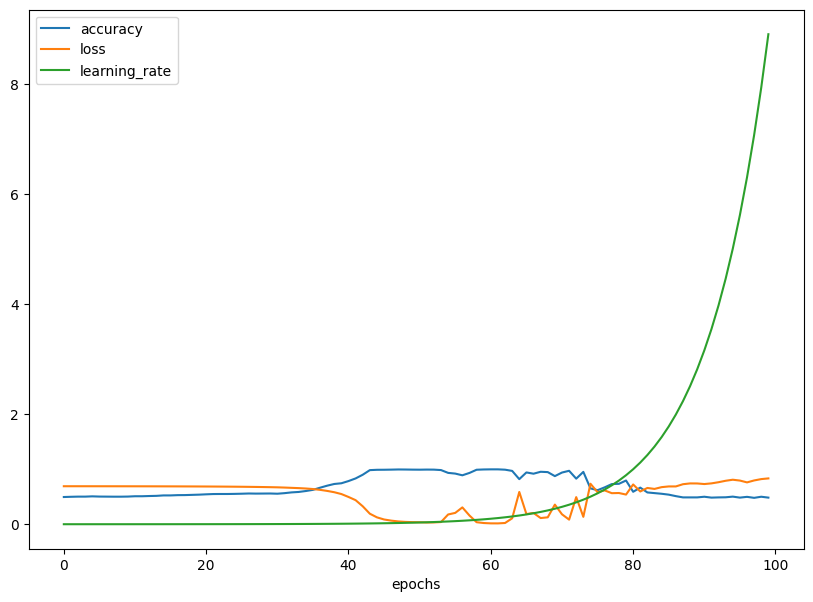

In [44]:
pd.DataFrame(history.history).plot(figsize=(10, 7), xlabel="epochs");

Text(0.5, 1.0, 'Learning Rate vs Loss')

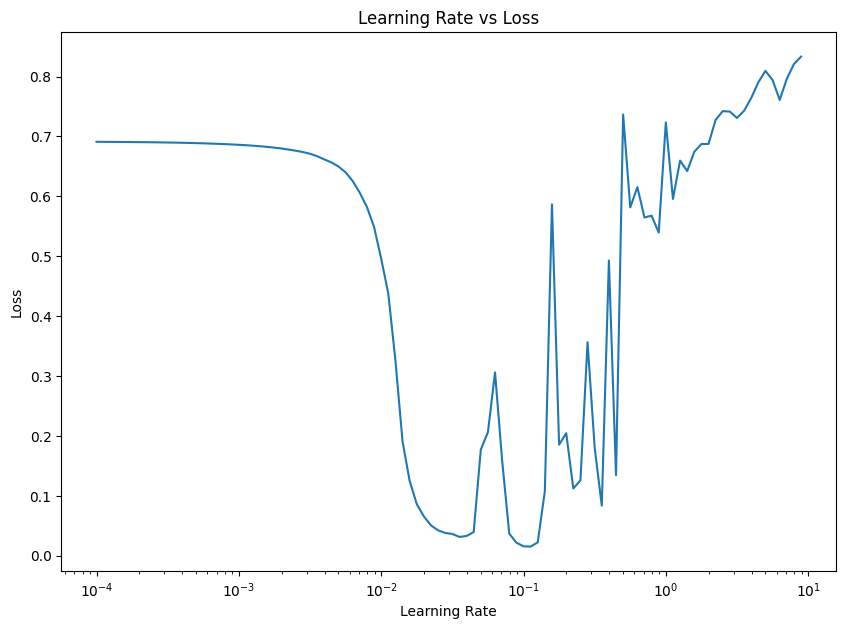

In [45]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100) / 20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history['loss'])
plt.xlabel('Learning Rate')
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")

In [46]:
# Let's try using a higher ideal learning rate with the same model as before

# Set random seed
tf.random.set_seed(42)

# Create the model
model10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model10.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                metrics=['accuracy'])

# Fit the model for 20 epochs (5 less than before)
history = model10.fit(X, y, epochs=20, verbose=0)


In [47]:
# Evaluate model 10 on the test dataset
model10.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0602  


[0.06020888686180115, 0.9950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step
doing binary classification


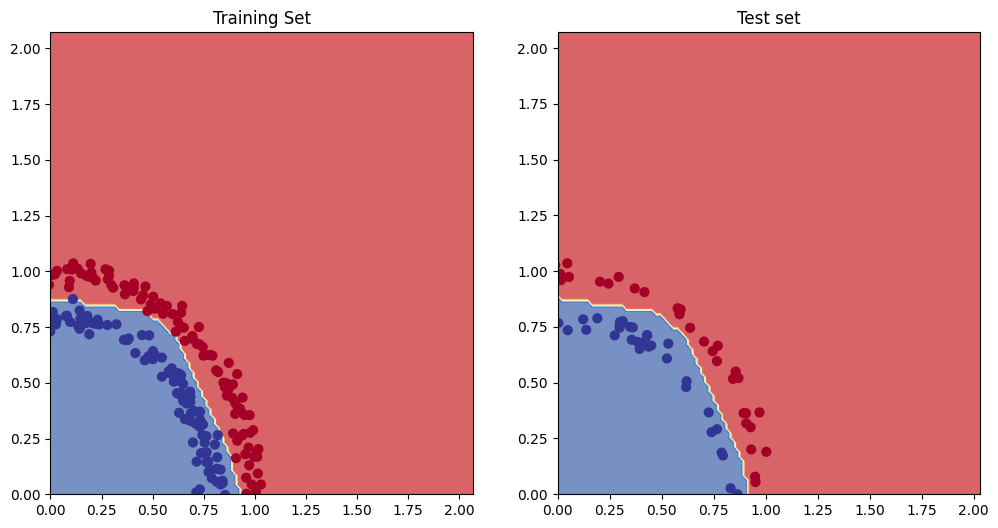

In [48]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Training Set')
plot_decision_boundary(model10, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test set')
plot_decision_boundary(model10, X_test, y_test)
plt.show()

## More classification evaluation methods

Alongside visualizing our model results as much as possible, there are a handful of other classification evaluation methods & metrics you should be familiar with:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report (from sklearn)

In [49]:
# Check the accuracy of our model10
loss, accuracy = model10.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0602 
Model loss on the test set: 0.06020888686180115
Model accuracy on the test set: 99.50%


How about confusion matrix?

In [50]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = model10.predict(X_test)

# Create a confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[100,   0],
       [  1,  99]])

How about we prettify our confusion matrix

**Note**: the confusion matrix code we're about to write is a remix of scikit-learn's plot_confusion_matrix function.

[`plot_confusion_matrix`](https://scikit-learn.org/0.24/modules/generated/sklearn.metrics.plot_confusion_matrix.html)

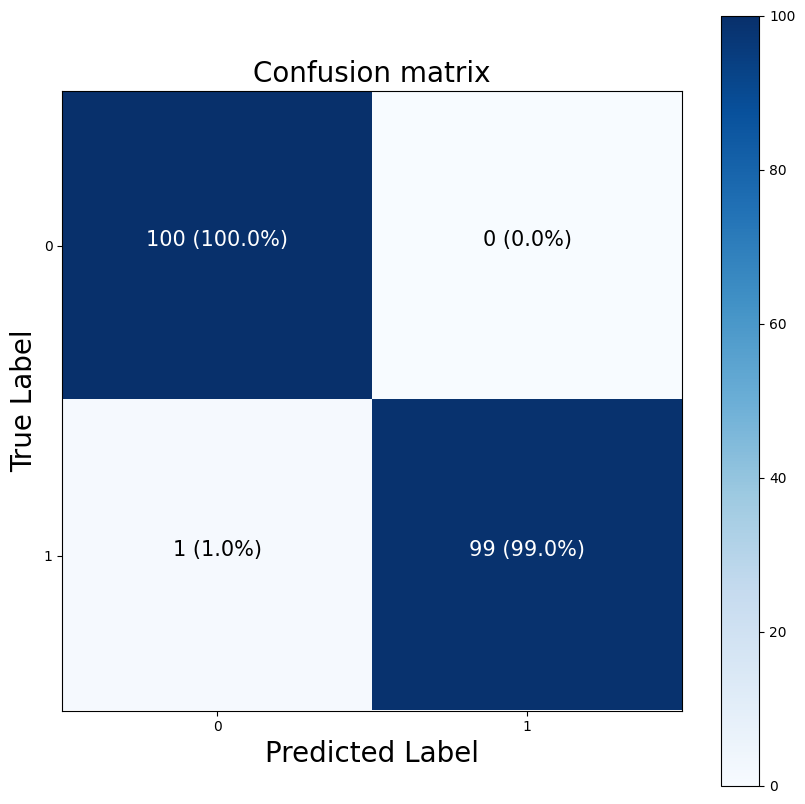

In [51]:
import itertools


# Create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
n_classes = cm.shape[0]

# Let's prettify it
fig, ax = plt.subplots(figsize=(10, 10))

# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'wide' each cell is
fig.colorbar(cax)

# Create classes
classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

# Label the axes
ax.set(title="Confusion matrix",
       xlabel="Predicted Label",
       ylabel="True Label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

# Set axis labels to bottom
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size = 15)

In [52]:
# functionizing our confusion matrix
def make_confusion_matrix(y_test, y_preds):
  ...

## Working wiht a larger example (multiclass classification)

When you have more than twon classes as an option, it's known as **multi-class classification**.
* This means if you have 3 different classes, it's multi-class classification.
* It also means if you have 100 different classes, it's multi-class classification.

To practice multi-class classification, we're going to build a neural network to classify images of different items of clothing.

In [53]:
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [54]:
# Show the first training example
print(f"Training sample:\n {X_train[0]}\n")
print(f"Training label:\n {y_train[0]}")

Training sample:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1 

In [55]:
# Check the shape of a single example
X_train[0].shape, y_train[0].shape

((28, 28), ())

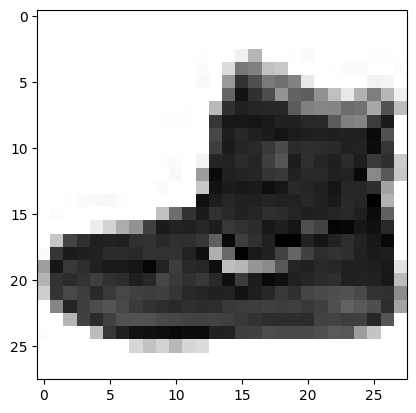

In [56]:
# Plot a single sample
plt.imshow(X_train[0], cmap='binary');

In [57]:
# Check our samples label
y_train[0]

np.uint8(9)

In [58]:
# Create a small list so we can index onto our traing labels so they're human-readable

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [59]:
len(class_names)

10

Text(0.5, 1.0, 'Ankle boot')

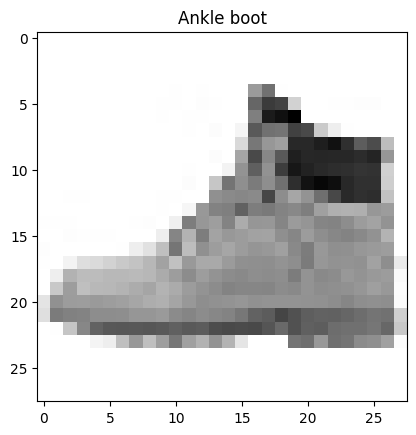

In [60]:
# Plot an example image and it's label

index_of_choice = 90
plt.imshow(X_train[index_of_choice], cmap='binary')
plt.title(class_names[y_train[index_of_choice]])

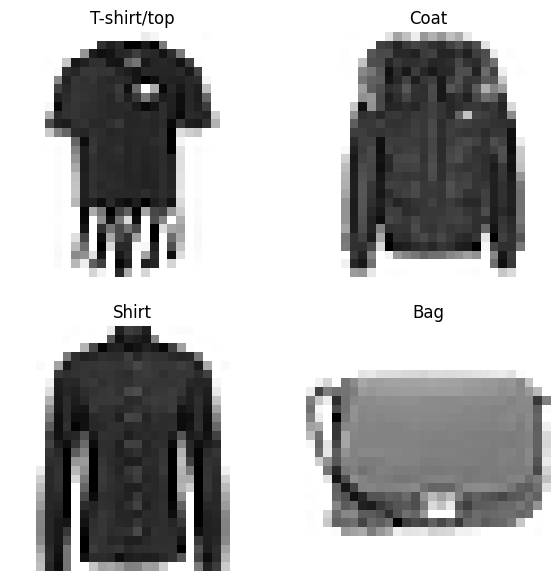

In [61]:
# Plot multiple random images of fashion MNIST

import random
plt.figure(figsize=(7, 7))
for i in range(4):
  ax = plt.subplot(2, 2, i+1)
  random_index = random.choice(range(len(X_train)))
  ax.imshow(X_train[random_index], cmap='binary')
  ax.set_title(class_names[y_train[random_index]])
  plt.axis('off')


## Building a multi-class classification model

For our multi-class classification model, we can use a similar architecture to our binary classifiers, however, we're going to have to tweak a few things:

* Input shape = 28 x 28 (the shape of one image)
* Output shae = 10 (one per class of clothing)
* Loss Function = tf.keras.losses.CategoricalCrosstentropy()
* Output layer activation =Softmax (not sigmoid)

In [63]:
# Set random seed
tf.random.set_seed(42)


# Create a model
model11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model11.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
               optimizer=tf.keras.optimizers.Adam(),
               metrics=['accuracy'])

# Fit the model
history = model11.fit(X_train,
                      y_train,
                      epochs=10,
                      validation_data=(X_test, y_test)
                      )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1292 - loss: 2.3060 - val_accuracy: 0.1972 - val_loss: 2.0015
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1938 - loss: 1.9113 - val_accuracy: 0.1964 - val_loss: 1.8525
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1990 - loss: 1.7956 - val_accuracy: 0.2000 - val_loss: 1.7817
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1969 - loss: 1.7442 - val_accuracy: 0.1991 - val_loss: 1.7200
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1971 - loss: 1.7238 - val_accuracy: 0.1967 - val_loss: 1.7333
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1983 - loss: 1.7220 - val_accuracy: 0.1986 - val_loss: 1.7140
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1969 - loss: 1.7208 - val_accuracy: 0.1954 - val_loss: 1.7147
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1975 - loss: 1.7123 - 